# **Import Libraries**

In [82]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# **Import Dataframe and Overview**

In [83]:
df = pd.read_csv("../data/clean_crime_data.csv") # clean crime data 
pop = pd.read_csv("../data/clean_pop.csv") # population data
df.head(10)

,crime_id,month,reported_by,falls_within,longitude,latitude,location,lsoa_code,lsoa_name,crime_type,last_outcome_category,year,month_num
0,e7b720d0e1302d2d06db7b28b29132eb194864d44d7921...,2024-01-01,City of London Police,City of London Police,-0.106220,51.518275,On or near B500,E01000916,Camden 027B,Theft from the person,Investigation complete; no suspect identified,2024,1
1,554675494f8d4c9bc7bdff89768eba0bea6fc8163b449b...,2024-01-01,City of London Police,City of London Police,-0.082993,51.516360,On or near Wormwood Street,E01032739,City of London 001F,Shoplifting,Court result unavailable,2024,1
2,c193d4b1bf3193dd3b226c87ec5654c1d8534196f21791...,2024-01-01,City of London Police,City of London Police,-0.086815,51.517007,On or near Circus Place,E01032739,City of London 001F,Shoplifting,Investigation complete; no suspect identified,2024,1
3,cafd96bd08d75cedcfa787ccfd339253b9d48cc1508030...,2024-01-01,City of London Police,City of London Police,-0.097291,51.514626,On or near Supermarket,E01032739,City of London 001F,Shoplifting,Court result unavailable,2024,1
4,b1943047143bc95275139b8d9c784ed9665c287748b940...,2024-01-01,City of London Police,City of London Police,-0.081902,51.517296,On or near Liverpool Street,E01032739,City of London 001F,Shoplifting,Investigation complete; no suspect identified,2024,1
5,aef7d89a2ccc415afa5b331122fbbf2f877d1cfc880c69...,2024-01-01,City of London Police,City of London Police,-0.095924,51.513882,On or near Shopping Area,E01032739,City of London 001F,Shoplifting,Investigation complete; no suspect identified,2024,1
6,67dfc3e8e30df735a87e821120d789db1fa80fdcf69efb...,2024-01-01,City of London Police,City of London Police,-0.081902,51.517296,On or near Liverpool Street,E01032739,City of London 001F,Shoplifting,Court result unavailable,2024,1
7,3f06c4b83263f80e5f3d453ee3d3240e145a2d19258c5f...,2024-01-01,City of London Police,City of London Police,-0.088785,51.517102,On or near Moorgate,E01032739,City of London 001F,Shoplifting,Court result unavailable,2024,1
8,ae9acde5ec020cba01dfb7f429e1adbdf2cb221b47c87f...,2024-01-01,City of London Police,City of London Police,-0.087772,51.510665,On or near Martin Lane,E01032739,City of London 001F,Shoplifting,Investigation complete; no suspect identified,2024,1
9,cf65b26cac56898fbffbc96a6c1fdff6f06989ac8da104...,2024-01-01,City of London Police,City of London Police,-0.086815,51.517007,On or near Circus Place,E01032739,City of London 001F,Shoplifting,Unable to prosecute suspect,2024,1


In [84]:
df.shape

(3782624, 13)

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3782624 entries, 0 to 3782623
Data columns (total 13 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   crime_id               object 
 1   month                  object 
 2   reported_by            object 
 3   falls_within           object 
 4   longitude              float64
 5   latitude               float64
 6   location               object 
 7   lsoa_code              object 
 8   lsoa_name              object 
 9   crime_type             object 
 10  last_outcome_category  object 
 11  year                   int64  
 12  month_num              int64  
dtypes: float64(2), int64(2), object(9)
memory usage: 375.2+ MB


# **Data Quality Assessment**

**Null Checks**

In [86]:
print("sum:\n", df.isnull().sum(), "\npercentage:\n", round(df.isnull().mean(),2)) # expected nulls in crime_id and lats_outcome_category

sum:
 crime_id                 178843
month                         0
reported_by                   0
falls_within                  0
longitude                     0
latitude                      0
location                      0
lsoa_code                     1
lsoa_name                     1
crime_type                    0
last_outcome_category    178843
year                          0
month_num                     0
dtype: int64 
percentage:
 crime_id                 0.05
month                    0.00
reported_by              0.00
falls_within             0.00
longitude                0.00
latitude                 0.00
location                 0.00
lsoa_code                0.00
lsoa_name                0.00
crime_type               0.00
last_outcome_category    0.05
year                     0.00
month_num                0.00
dtype: float64


**Duplicate Checks**

In [87]:
df.duplicated().sum()

np.int64(0)

**Time Range Checks**

In [88]:
df["month"].min(), df["month"].max()

('2024-01-01', '2026-01-01')

# **Crimes Volume by Police Force Region (Jurisdicton)**

In [89]:
region_crime = df["falls_within"].value_counts()
region_crime

falls_within
Metropolitan Police Service    1975487
West Midlands Police            659474
West Yorkshire Police           590734
Thames Valley Police            377677
Surrey Police                   161891
City of London Police            17361
Name: count, dtype: int64

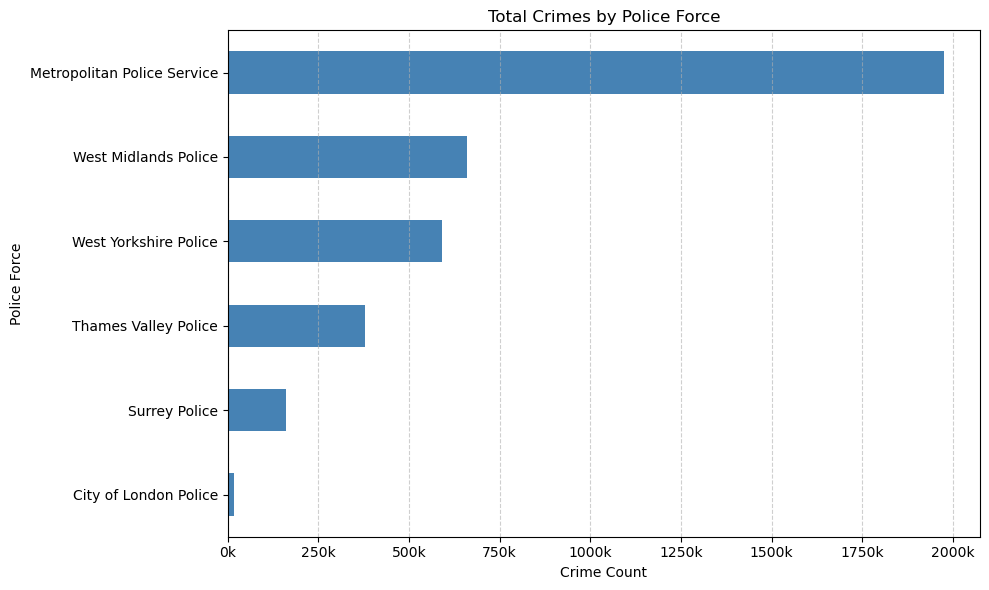

In [90]:
# visualisation
ax = region_crime.sort_values().plot(
    kind="barh",
    figsize=(10,6),
    color="steelblue"
)

plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.title("Total Crimes by Police Force")
plt.xlabel("Crime Count")
plt.ylabel("Police Force")

# format x axis to thousands
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k'))

plt.tight_layout()
plt.show()

# **Crimes Volume Per Capita by Police Force**

In [91]:
# crimes per lsoa within each police force
crime_pop = (
    df.groupby(["falls_within", "lsoa_code"])
      .size()
      .reset_index(name="crime_count")
)

# merge population onto crime_lsoa
crime_pop = crime_pop.merge(
    pop,
    left_on="lsoa_code",
    right_on = "lsoa_2021_code",
    how="left"
)

# check result
print(crime_pop.columns.tolist())
print(crime_pop[["falls_within", "lsoa_code", "crime_count", "total"]].head())
print(crime_pop["total"].isna().sum())

['falls_within', 'lsoa_code', 'crime_count', 'lad_2021_code', 'lad_2021_name', 'lsoa_2021_code', 'lsoa_2021_name', 'total', 'f0_to_15', 'f16_to_29', 'f30_to_44', 'f45_to_64', 'f65_and_over', 'm0_to_15', 'm16_to_29', 'm30_to_44', 'm45_to_64', 'm65_and_over']
            falls_within  lsoa_code  crime_count  total
0  City of London Police  E01000001          298   2172
1  City of London Police  E01000002          807   2044
2  City of London Police  E01000003          223   2444
3  City of London Police  E01000005         1301   2391
4  City of London Police  E01000013            1   1973
0


In [92]:
crime_rate = crime_pop.groupby("falls_within").agg(
    total_crimes=("crime_count", "sum"),
    total_population=("total", "sum")
)

crime_rate["crime_rate_per_1000"] = (
    crime_rate["total_crimes"] / crime_rate["total_population"]
) * 1000

print("\nRegional crime summary:")
print(crime_rate)


Regional crime summary:
                             total_crimes  total_population  \
falls_within                                                  
City of London Police               17361            412512   
Metropolitan Police Service       1975486          18464908   
Surrey Police                      161891           1454370   
Thames Valley Police               377677           2648317   
West Midlands Police               659474           3113162   
West Yorkshire Police              590734           2513485   

                             crime_rate_per_1000  
falls_within                                      
City of London Police                  42.086048  
Metropolitan Police Service           106.985965  
Surrey Police                         111.313490  
Thames Valley Police                  142.610194  
West Midlands Police                  211.834142  
West Yorkshire Police                 235.025870  


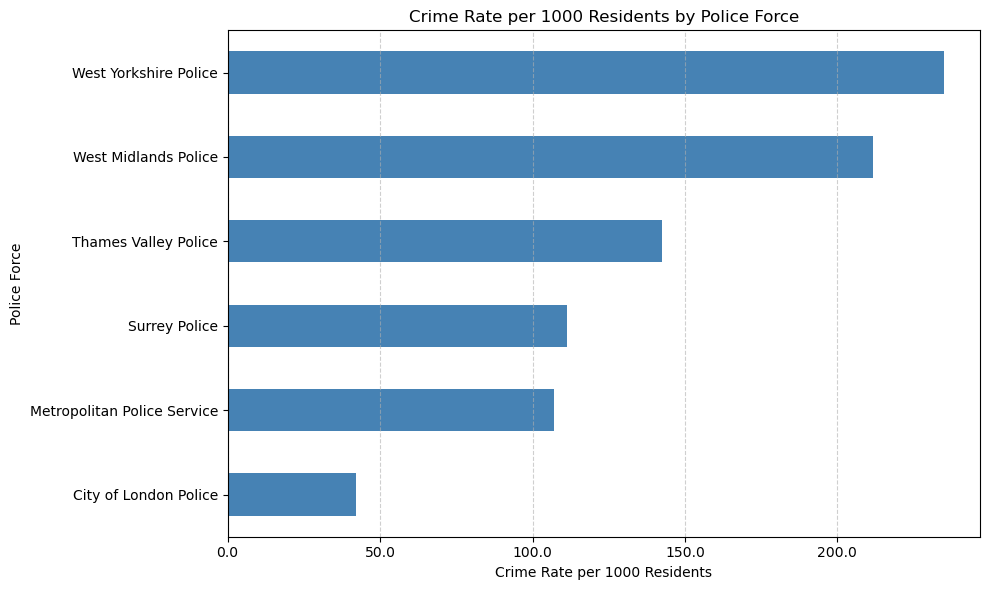

In [93]:
# visualisations
ax = crime_rate["crime_rate_per_1000"].sort_values().plot(
    kind="barh",
    figsize=(10,6),
    color="steelblue"
)

plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.title("Crime Rate per 1000 Residents by Police Force")
plt.xlabel("Crime Rate per 1000 Residents")
plt.ylabel("Police Force")

ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

plt.tight_layout()
plt.show()

# **Distribution by Police Force**

**Crime Type**

Text(95.7222222222222, 0.5, 'Police Force')

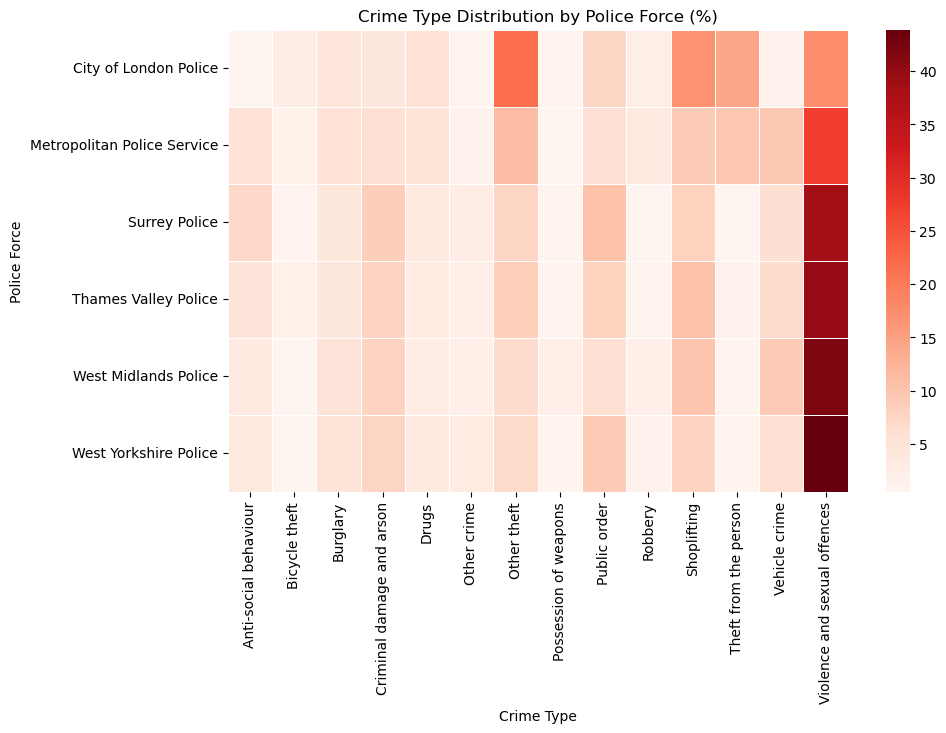

In [94]:
ct_region = pd.crosstab(
    df["falls_within"],
    df["crime_type"],
    normalize="index"
) * 100

plt.figure(figsize=(10,6))

sns.heatmap(ct_region, cmap="Reds", linewidths = 0.5)

plt.title("Crime Type Distribution by Police Force (%)")
plt.xlabel("Crime Type")
plt.ylabel("Police Force")

**Outcome**

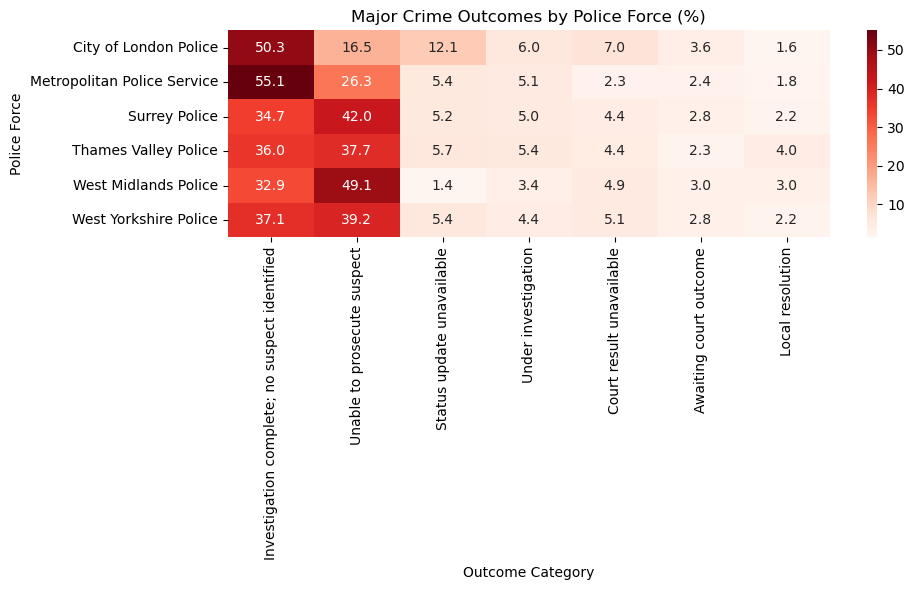

In [95]:
# get outcome percentages by police force
outcome_region = pd.crosstab(
    df["falls_within"],
    df["last_outcome_category"],
    normalize="index"
) * 100

# select the top outcomes overall
top_outcomes = df["last_outcome_category"].value_counts().head(7).index

# filter the table
outcome_region = outcome_region[top_outcomes]

# plot heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    outcome_region,
    annot=True,
    fmt=".1f",
    cmap="Reds"
)

plt.title("Major Crime Outcomes by Police Force (%)")
plt.ylabel("Police Force")
plt.xlabel("Outcome Category")

plt.tight_layout()
plt.show()

# **Time Analysis**

**Total crime across the two year timeframe**

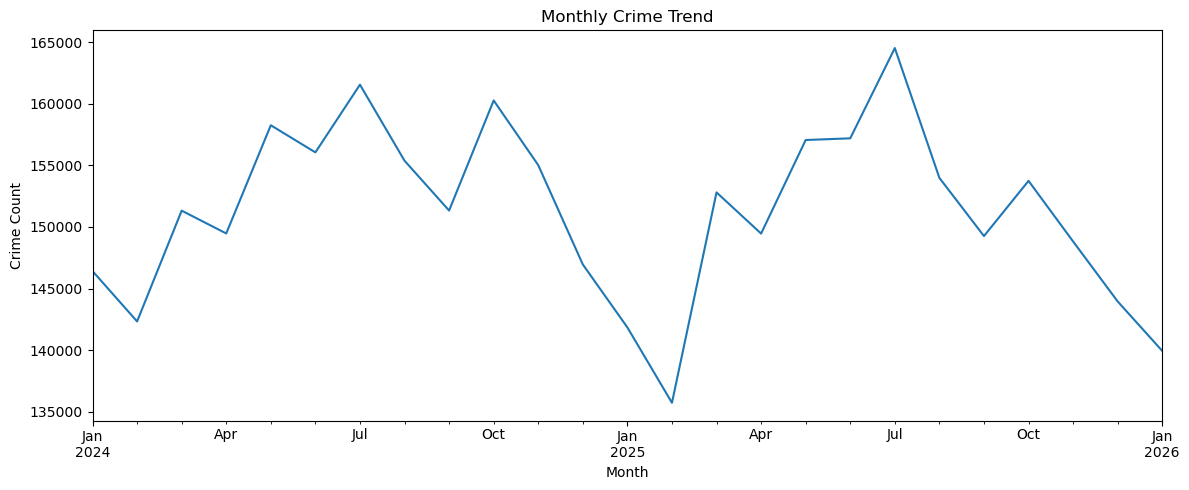

In [96]:
# convert month column to datetime
df["month"] = pd.to_datetime(df["month"])

# total crimes per month
monthly_crime = df.groupby("month").size()

# line chart of monthly crime trend
plt.figure(figsize=(12, 5))
monthly_crime.plot()

plt.title("Monthly Crime Trend")
plt.xlabel("Month")
plt.ylabel("Crime Count")
plt.tight_layout()
plt.show()

**Crime Changes recorded by Police Forces**

<Figure size 1400x700 with 0 Axes>

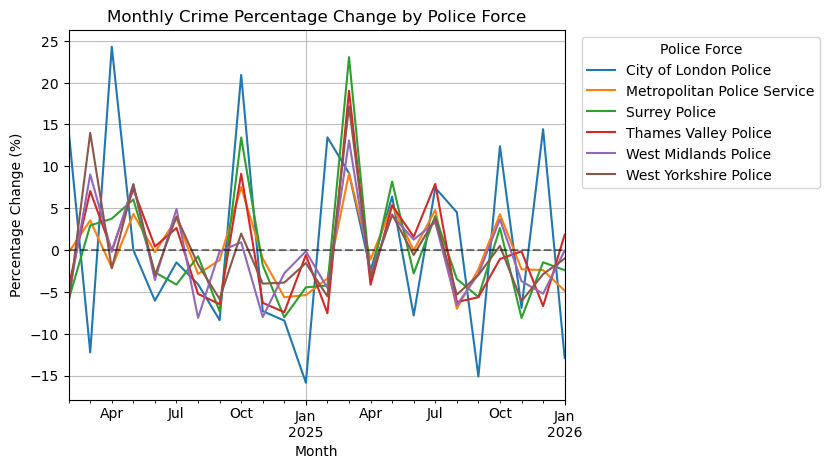

In [97]:
# group by month and police force
monthly_force = df.groupby(["month", "falls_within"]).size().unstack()

# calculate month-to-month percentage change
pct_change = monthly_force.pct_change() * 100
pct_change = pct_change.dropna() # first month has no change
plt.figure(figsize=(14,7))
pct_change.plot()

plt.title("Monthly Crime Percentage Change by Police Force")
plt.xlabel("Month")
plt.ylabel("Percentage Change (%)")
plt.grid(alpha=0.8)
plt.axhline(0, linestyle="--", color="black", alpha=0.5)

plt.legend(title="Police Force", bbox_to_anchor=(1.02,1), loc="upper left")

plt.show()

# **Univariate Analysis**

**Crime Type**

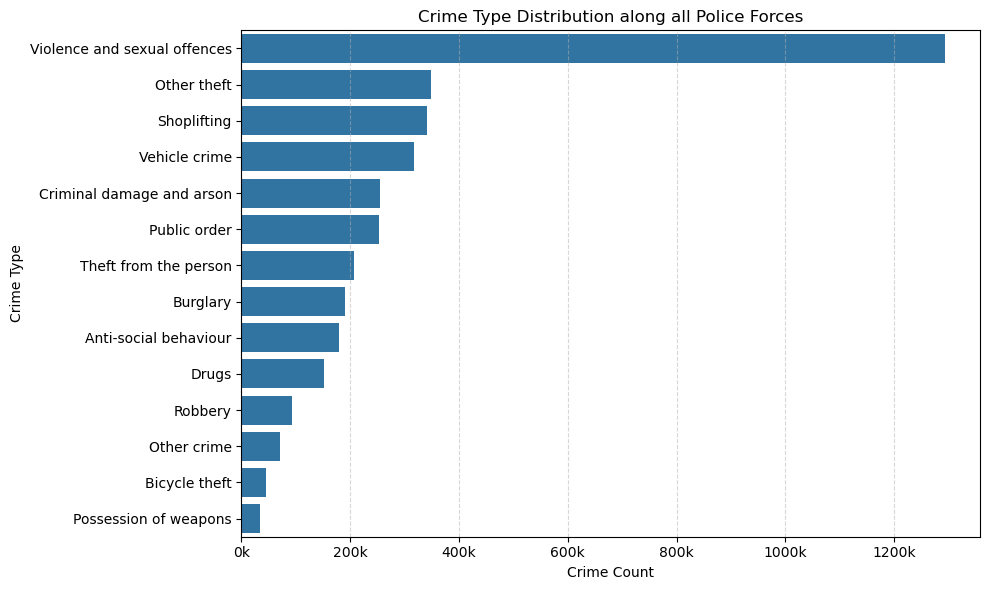

In [99]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    y="crime_type",
    data=df,
    order=df["crime_type"].value_counts().index # ranking by most crime count
)

plt.title("Crime Type Distribution along all Police Forces")
plt.xlabel("Crime Count")
plt.ylabel("Crime Type")

# format x-axis to show thousands (k)
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k')
)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()

**Crime outcomes**

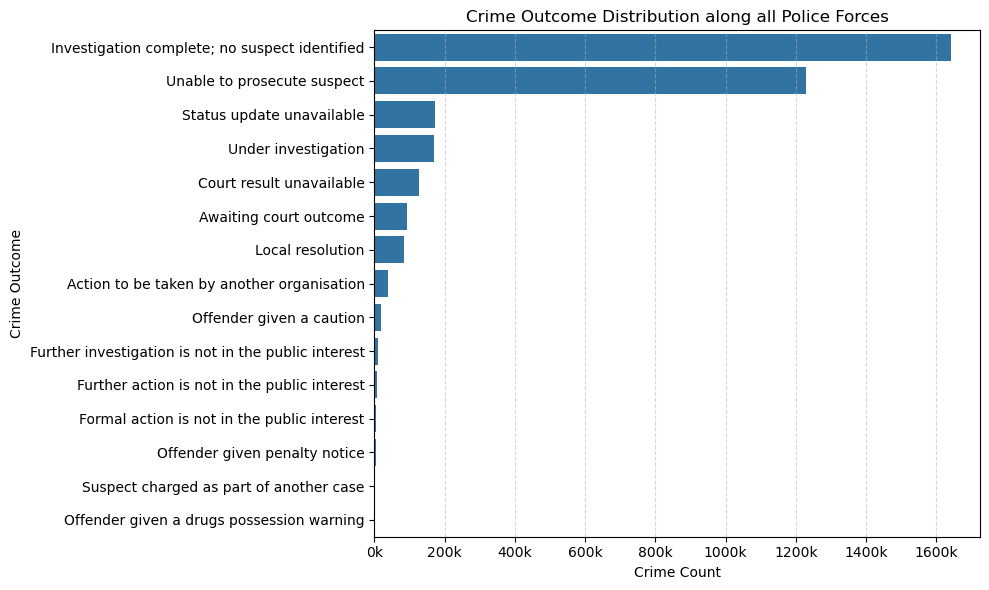

In [100]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    y="last_outcome_category",
    data=df,
    order=df["last_outcome_category"].value_counts().index # ranking by most crime count
)

plt.title("Crime Outcome Distribution along all Police Forces")
plt.xlabel("Crime Count")
plt.ylabel("Crime Outcome")

# format x-axis to show thousands (k)
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k')
)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()

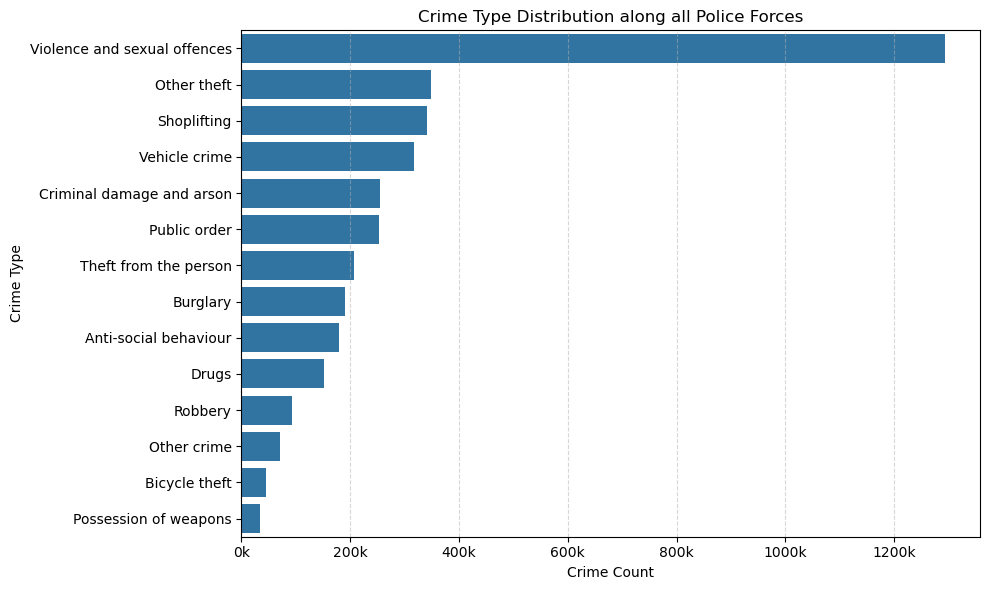

In [101]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    y="crime_type",
    data=df,
    order=df["crime_type"].value_counts().index # ranking by most crime count
)

plt.title("Crime Type Distribution along all Police Forces")
plt.xlabel("Crime Count")
plt.ylabel("Crime Type")

# format x-axis to show thousands (k)
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k')
)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()

# **Crime Map**

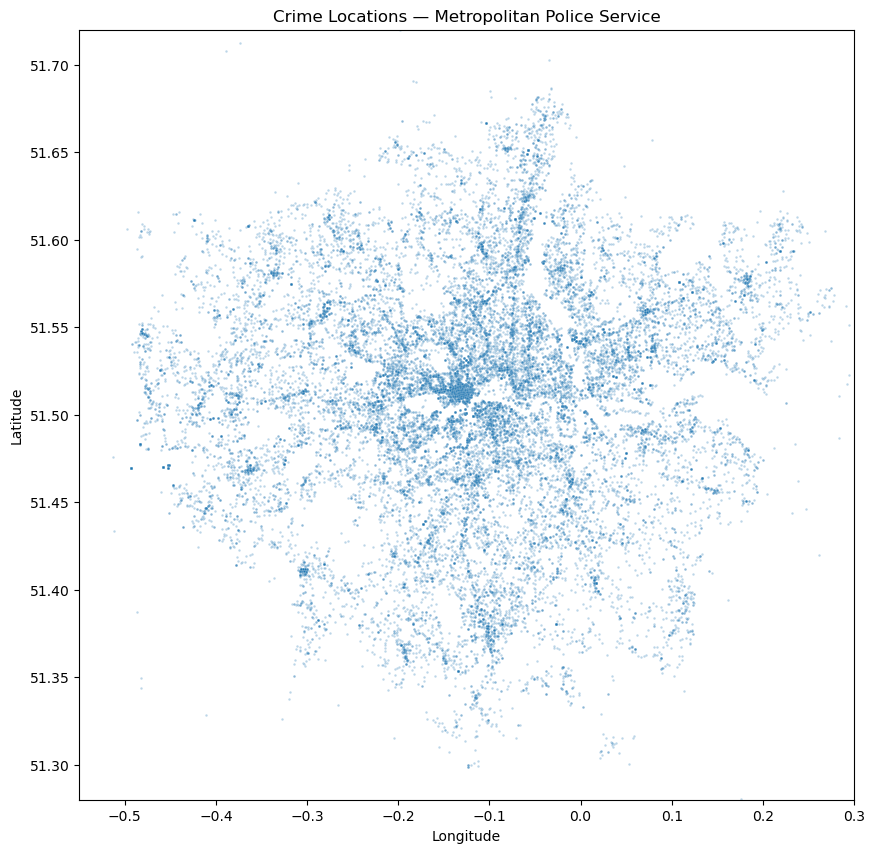

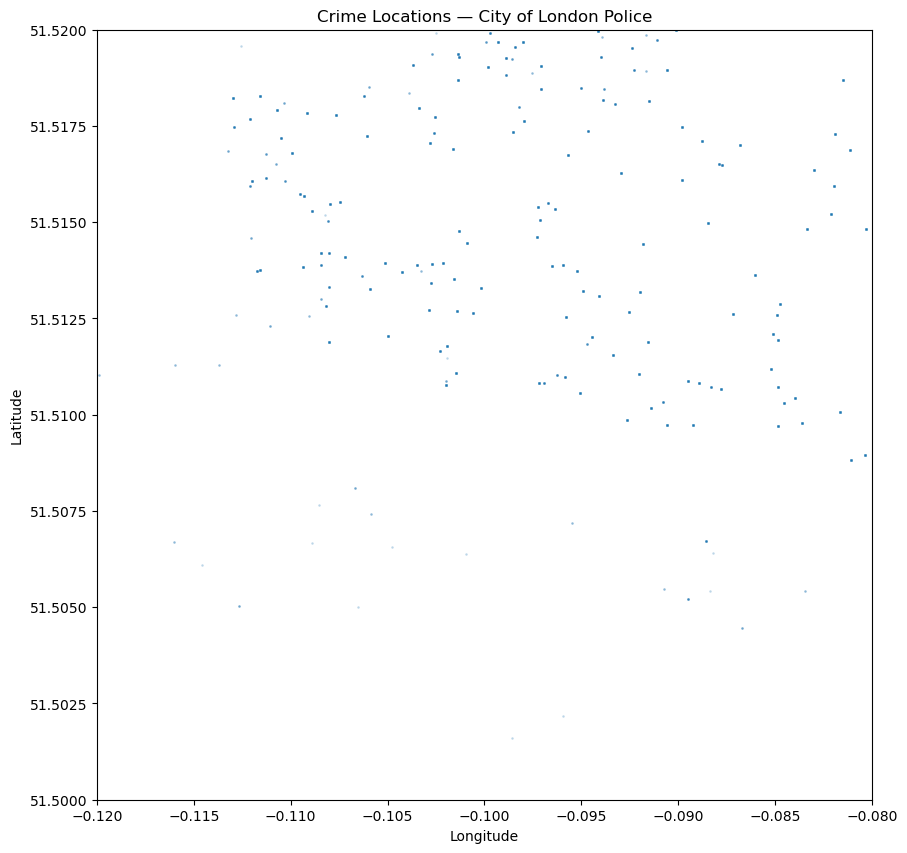

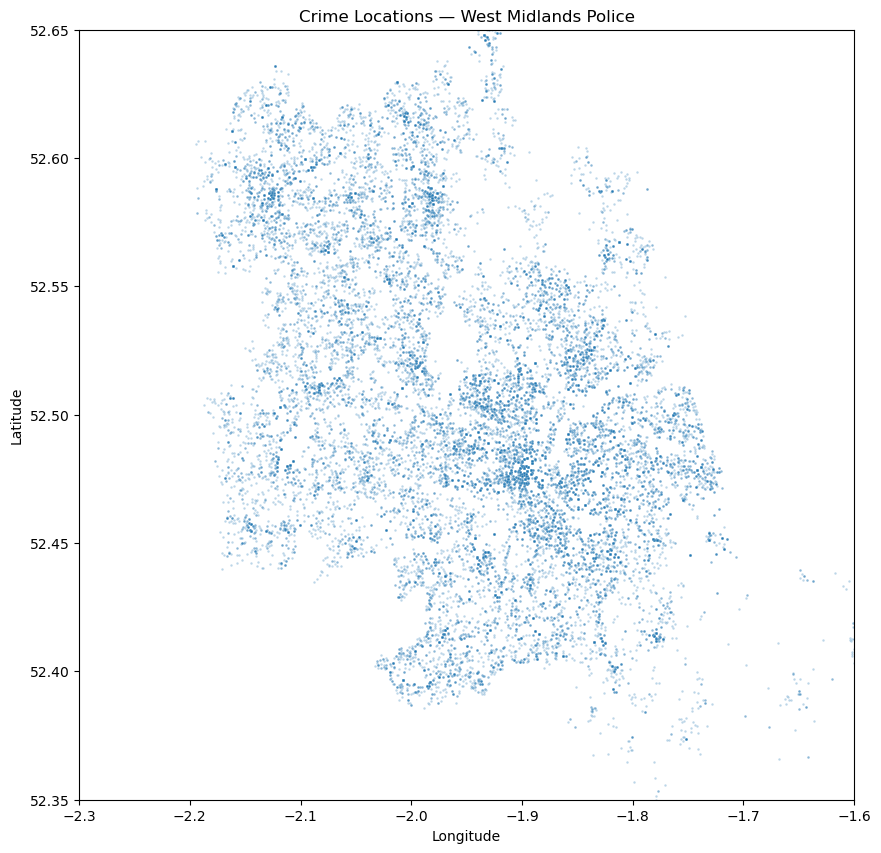

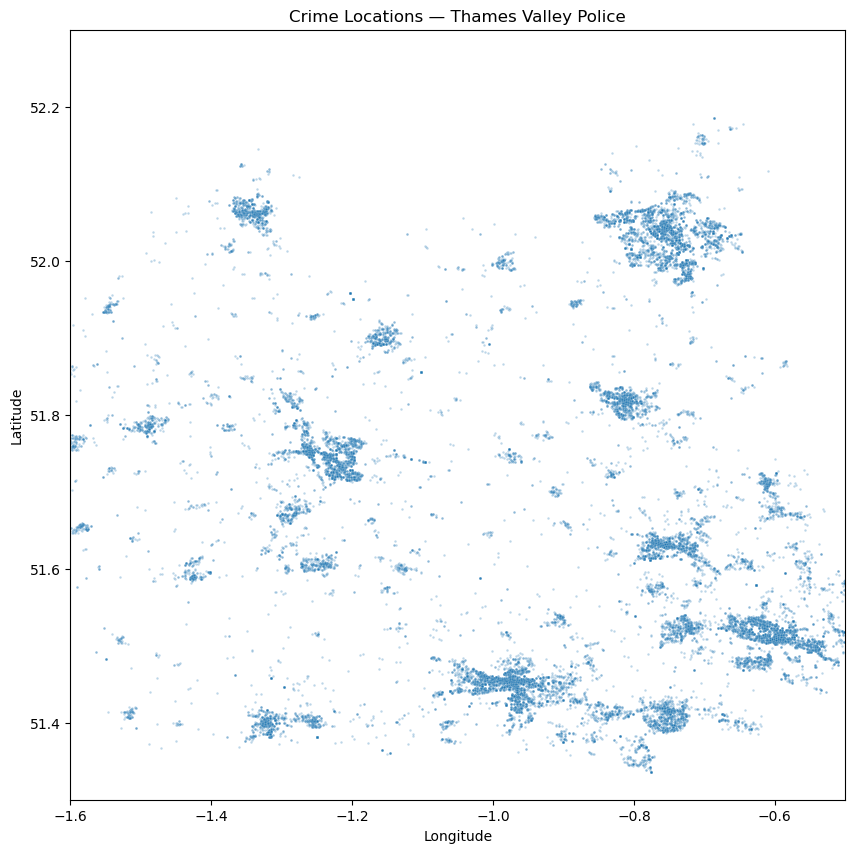

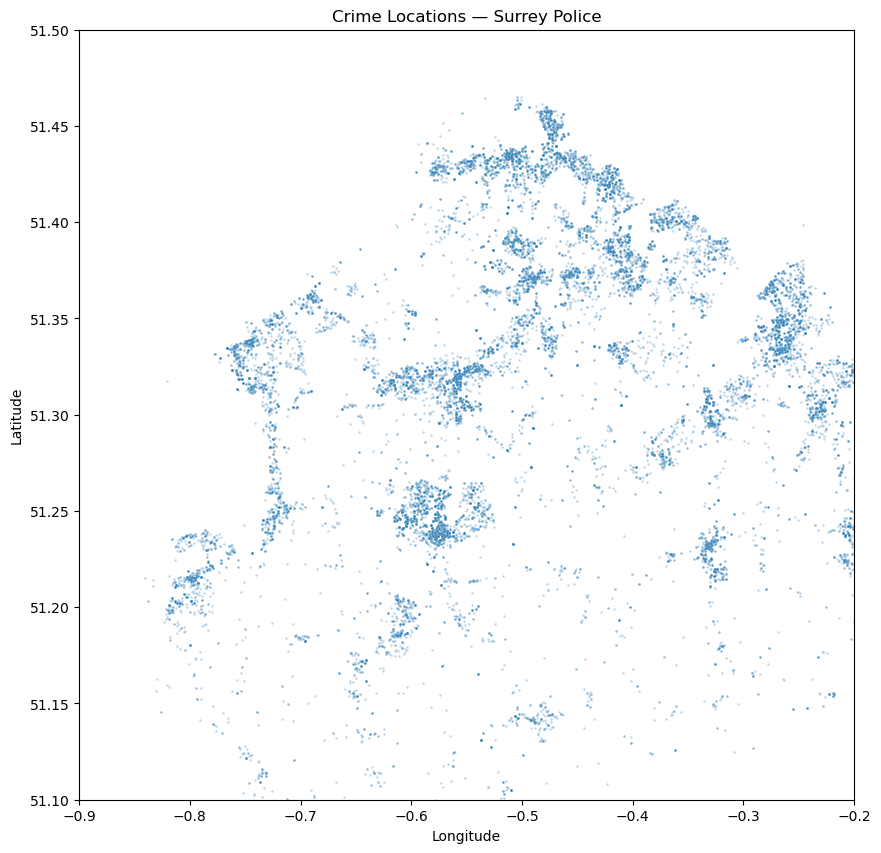

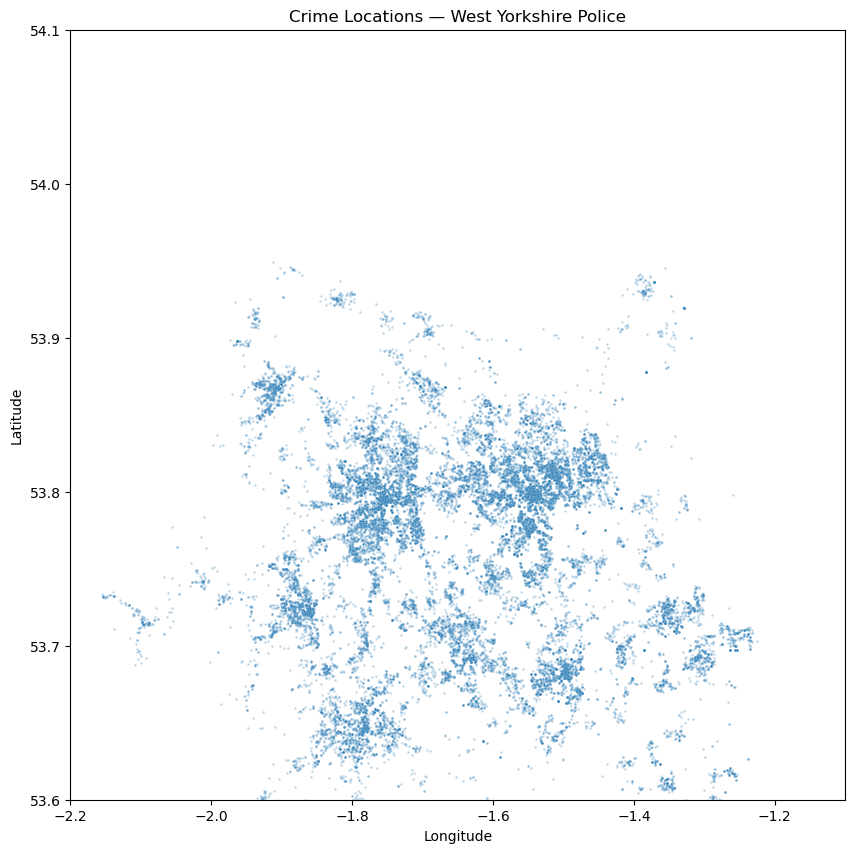

In [102]:
zoom_levels = {
    "Metropolitan Police Service": (-0.55, 0.30, 51.28, 51.72),
    "City of London Police": (-0.12, -0.08, 51.50, 51.52),
    "West Midlands Police": (-2.3, -1.6, 52.35, 52.65),
    "Thames Valley Police": (-1.6, -0.5, 51.3, 52.3),
    "Surrey Police": (-0.9, -0.2, 51.1, 51.5),
    "West Yorkshire Police": (-2.2, -1.1, 53.6, 54.1)
}

def plot_crime_scatter(df, police_force, bounds):

    # filter data
    data = df[df["falls_within"] == police_force].copy()

    # remove missing coordinates
    data = data.dropna(subset=["latitude", "longitude"])

    if len(data) == 0:
        print(f"No data for {police_force}")
        return

    # optional sampling (for large datasets)
    data = data.sample(min(30000, len(data)), random_state=42)

    plt.figure(figsize=(10,10))

    sns.scatterplot(
        x="longitude",
        y="latitude",
        data=data,
        alpha=0.3,
        s=3
    )

    xmin, xmax, ymin, ymax = bounds
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)

    plt.title(f"Crime Locations — {police_force}")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")

    plt.show()

for force, bounds in zoom_levels.items():
    plot_crime_scatter(df, force, bounds)